In [1]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [3]:
import os
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGCHAIN_PROJECT'] = 'advance-rag'
os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")
os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY")

from langchain_groq import ChatGroq
llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)

## Part 10: Logical and Semantic Routing

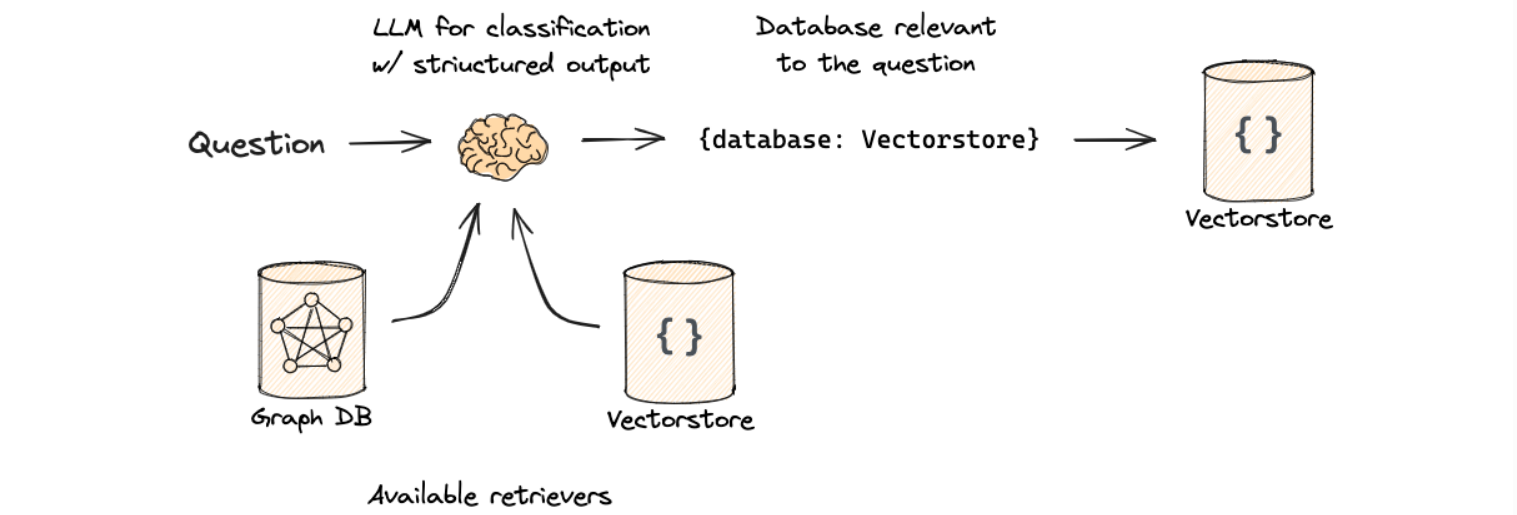

In [4]:
from typing import Literal

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq

# Data model
class RouteQuery(BaseModel):
    """Route a user query to most relevant data source."""
    
    datasource: Literal['python_docs', 'js_docs', 'golang_docs'] = Field(
        ...,
        description="Given a user question choose which datasource would be more relevant for answering their question"
    )
    
# LLM with function call
structured_llm = llm.with_structured_output(RouteQuery)

# Prompt
system = """You are an expert at routing a user question to the appropriate data source

Based on the programming language the question is referring to, route it to the relevant data source. """

prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human", "{question}")
    ]
)

# Define router
router = prompt | structured_llm

In [6]:
question = """Why there am i getting index error
lst = [1, 2, 3, 5, 7]
print(lst[10])"""

result = router.invoke({"question": question})
result

RouteQuery(datasource='python_docs')

In [7]:
def choose_route(result):
    if 'python_docs' in result.datasource.lower():
        return "Chain for python_docs"
    elif "js_docs" in result.datasource.lower():
        return "Chain for js_docs"
    else:
        return "Chain for golang_docs"
    
print(choose_route(result))

Chain for python_docs


#### Semantic Routing

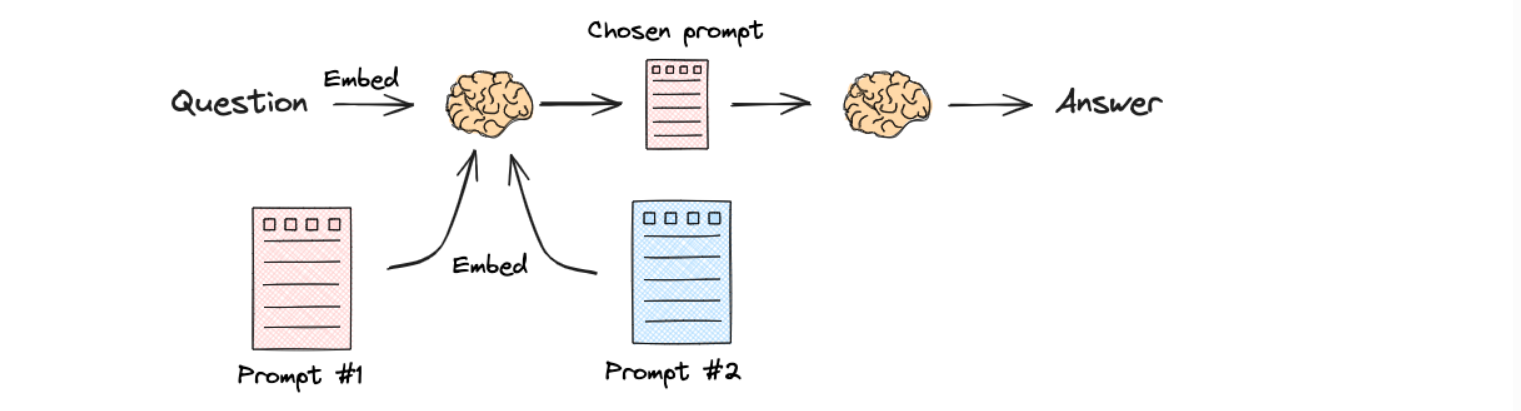

In [11]:
from langchain_community.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_huggingface import HuggingFaceEmbeddings

#Two prompts
physics_template = """You are a smart physics professor. \
    You are great at answering question about physics in a concise and easy to understand manner. \
    Why you don't know to answer the question you admit that you don't know the answer.
    
    Here is the question:
    {query}"""
    
math_template = """You are a very good mathematician. \
    You are great at answering math questions. You are so good that you are able to break down hard problems into their component parts, \
    answer the component parts, and then put together to answer the broader question.
    
    Here is the question:
    {query}"""
    
#Embeddings

model_name = "BAAI/bge-large-en-v1.5"
hf_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={
        "device": "cuda",  # Use RTX 4070
    },
    encode_kwargs={
        "normalize_embeddings": True,
        "batch_size": 32,
    },
)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4806.16it/s]


In [16]:
prompt_templates = [physics_template, math_template]
prompt_embeddings = hf_embeddings.embed_documents(prompt_templates)

#Route question to prompt
def prompt_router(input):
    
    query_embedding = hf_embeddings.embed_query(input['query'])
    # print(query_embedding)
    # print(prompt_embeddings)
    
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    most_similar = prompt_templates[similarity.argmax()]
    # print(prompt_templates)
    
    # print(similarity)
    
    print("Using MATH" if most_similar==math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)


# inp = {'query':'Momentum velocity'}

# prompt_router(inp)

chain = (
    {'query': RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | llm
    | StrOutputParser()
)

print(chain.invoke('What is an imaginary line in algebra?'))

Using MATH
In algebra, an imaginary line is not exactly a line in the classical sense, but rather a concept that helps us visualize and understand complex numbers.

To break it down, let's start with the basics:

1. **Real numbers**: These are the numbers we're familiar with, like 1, 2, 3, etc. We can plot these numbers on a number line, which is a straight line where each point corresponds to a real number.
2. **Complex numbers**: These are numbers that have both a real and an imaginary part. They can be written in the form a + bi, where a is the real part and b is the imaginary part. The imaginary part is multiplied by the imaginary unit i, which is defined as the square root of -1 (i = √(-1)).

Now, when we try to visualize complex numbers, we can't simply plot them on the same number line as real numbers. That's where the concept of an imaginary line comes in.

3. **Imaginary line**: An imaginary line, also known as the imaginary axis, is a vertical line that intersects the real nu

## Part 11: Query structuring for metadata filters

Many vectorstores contain metadata fields. This makes it possible to filter for specific chunks based on metadata.

In [30]:
import datetime
from typing import Literal, Optional, Tuple
from pydantic import BaseModel, Field

class TutorialSearch(BaseModel):
    """Search over a database of tutorial videos about a software library."""

    content_search: str = Field(
        ...,
        description="Similarity search query applied to video transcripts.",
    )
    title_search: str = Field(
        ...,
        description=(
            "Alternate version of the content search query to apply to video titles. "
            "Should be succinct and only include key words that could be in a video "
            "title."
        ),
    )
    min_view_count: Optional[int] = Field(
        None,
        description="Minimum view count filter, inclusive. Only use if explicitly specified.",
    )
    max_view_count: Optional[int] = Field(
        None,
        description="Maximum view count filter, exclusive. Only use if explicitly specified.",
    )
    earliest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Earliest publish date filter, inclusive. Only use if explicitly specified.",
    )
    latest_publish_date: Optional[datetime.date] = Field(
        None,
        description="Latest publish date filter, exclusive. Only use if explicitly specified.",
    )
    min_length_sec: Optional[int] = Field(
        None,
        description="Minimum video length in seconds, inclusive. Only use if explicitly specified.",
    )
    max_length_sec: Optional[int] = Field(
        None,
        description="Maximum video length in seconds, exclusive. Only use if explicitly specified.",
    )

    def pretty_print(self) -> None:
        for field, value in self.model_dump(
            exclude_none=True,
            exclude_defaults=True
        ).items():
            print(f"{field}: {value}")

In [31]:
from langchain_core.prompts import ChatPromptTemplate

system = """You are an expert at converting user questions into database queries. \
You have access to a database of tutorial videos about a software library for building LLM-powered applications. \
Given a question, return a database query optimized to retrieve the most relevant results.

If there are acronyms or words you are not familiar with, do not try to rephrase them."""
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)
structured_llm = llm.with_structured_output(TutorialSearch)
query_analyzer = prompt | structured_llm

In [34]:
query_analyzer.invoke({"question": "rag from scratch"}).pretty_print()

content_search: building from scratch
title_search: RAG tutorial


In [35]:
query_analyzer.invoke(
    {"question": "videos on chat langchain published in 2023"}
).pretty_print()

content_search: chat langchain
title_search: langchain chat
earliest_publish_date: 2023-01-01
latest_publish_date: 2023-12-31


In [36]:
query_analyzer.invoke(
    {"question": "videos that are focused on the topic of chat langchain that are published before 2024"}
).pretty_print()

content_search: chat langchain
title_search: langchain chat
latest_publish_date: 2024-01-01


In [37]:
query_analyzer.invoke(
    {
        "question": "how to use multi-modal models in an agent, only videos under 5 minutes"
    }
).pretty_print()

content_search: multi-modal models in an agent
title_search: multi-modal agent
max_length_sec: 300
